<h1 style="background-color: transparent; color: #ADD8E6; padding: 10px; text-align: left; font-size: 36px;">
    NETFLIX CUSTOMER CHURN PREDICTION
</h1>

<h1 style="background-color: #ADD8E6; color: white; padding: 10px; border-radius: 5px; text-align: center;">
    INTRODUCTION
</h1>

<h1 style="background-color: transparent; color: #ADD8E6; padding: 10px; text-align: left;">
    BUSINESS GOAL
</h1>

<div style="padding: 15px; margin-top: 10px; color: black;">
The main business goal for the Netflix Customer Churn Prediction project is to proactively protect and stabilize annual revenue by ensuring subscribers stay longer. Instead of waiting for customers to cancel, the system identifies high-risk individuals—primarily those showing low engagement, such as reduced daily watch time—allowing the company to intervene first. By focusing retention efforts solely on these most vulnerable customers, the project aims to achieve a 15% reduction in churn, which directly translates to $42 million in protected annual revenue. Ultimately, this shift enables Netflix to increase the average value of its customers and allocate its marketing and content resources far more efficiently.
</div>


<h1 style="background-color: transparent; color: #ADD8E6; padding: 10px; text-align: left;">
    DATA OVERVIEW
</h1>

<div style="padding: 15px; margin-top: 10px; color: black;">
The project utilizes a dataset comprising 5,000 anonymized customer records, with the primary goal being the prediction of the binary churn outcome (retained or churned). The data is well-balanced, meaning approximately 50% of the customers have churned and 50% have been retained, eliminating the need for complex sampling techniques to correct for class imbalance. The features are broadly categorized into three groups: static customer profiles (including age, gender, geographic region, and payment method); subscription details (such as monthly fee and subscription tier); and crucially, behavioral metrics. These behavioral metrics, like the amount of content consumed and the frequency of platform logins, were confirmed by the predictive model to be the most powerful indicators of a customer's intent to leave. Prior to analysis, features were engineered to capture derived concepts, such as value-per-hour consumed**, which combines the subscription cost with usage data, providing a unified metric of a customer's perceived value from the service.
</div>

<h1 style="background-color: transparent; color: #ADD8E6; padding: 10px; text-align: left; font-size: 24px;">
    1. DATA PREPARATION AND CLEANING
</h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score

import joblib

In [2]:
df = pd.read_csv("../data/netflix_customer_churn.csv")

In [3]:
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


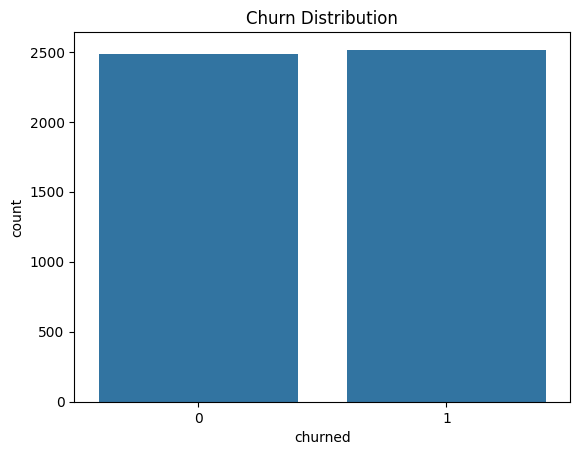

In [4]:
sns.countplot(x='churned', data=df)
plt.title("Churn Distribution")
plt.show()

### Dropthe customer_id column, as it's unique and has no predictive power

In [5]:
df = df.drop('customer_id', axis=1)

In [6]:
df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


## Feature Engineering

### Value Metric: Create a new feature like value_per_hour by dividing monthly_fee by watch_hours.A low value suggests the customer is overpaying for low usage.

In [7]:
import numpy as np
df['value_per_hour'] = df['monthly_fee'] / df['watch_hours'] 

In [8]:
df.head()

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,value_per_hour
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,0.610319
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,19.985714
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama,0.857230
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror,3.988914
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,7.402116


### Consider bucketing last_login_days into categories (e.g., 'Low Inactivity', 'High Inactivity') to capture non-linear effects,  although a continuous value works well for tree-based models too.

In [9]:
bins = [0, 7, 30, 60]
labels = ['High Activity (0-7d)', 'Moderate Inactivity (8-30d)', 'High Inactivity (31-60d)']
df['inactivity_category'] = pd.cut(
    df['last_login_days'],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

In [10]:
df

,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,value_per_hour,inactivity_category
0,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,0.610319,Moderate Inactivity (8-30d)
1,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,19.985714,Moderate Inactivity (8-30d)
2,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama,0.857230,Moderate Inactivity (8-30d)
3,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror,3.988914,Moderate Inactivity (8-30d)
4,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,7.402116,Moderate Inactivity (8-30d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,19,Female,Basic,49.17,11,Europe,Desktop,8.99,0,Credit Card,4,4.10,Drama,0.182835,Moderate Inactivity (8-30d)
4996,67,Female,Basic,9.24,2,North America,Desktop,8.99,0,PayPal,3,3.08,Documentary,0.972944,High Activity (0-7d)
4997,66,Male,Standard,16.55,49,South America,Desktop,13.99,1,Debit Card,2,0.33,Action,0.845317,High Inactivity (31-60d)
4998,59,Female,Basic,9.12,3,Europe,Laptop,8.99,0,Credit Card,4,2.28,Sci-Fi,0.985746,High Activity (0-7d)


## Handle Categorical Variables

### Convert all categorical (text) columns—like gender, subscription_type, region, device, payment_method, and favorite_genre—using One-Hot Encoding (e.g., pd.get_dummies). This creates a new binary column for each category

In [11]:
categorical_cols = [
    'gender',
    'subscription_type',
    'region',
    'device',
    'payment_method',
    'favorite_genre',
    'inactivity_category'
] 

In [12]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [13]:
df_encoded.head()

,age,watch_hours,last_login_days,monthly_fee,churned,number_of_profiles,avg_watch_time_per_day,value_per_hour,gender_Male,gender_Other,...,payment_method_Gift Card,payment_method_PayPal,favorite_genre_Comedy,favorite_genre_Documentary,favorite_genre_Drama,favorite_genre_Horror,favorite_genre_Romance,favorite_genre_Sci-Fi,inactivity_category_Moderate Inactivity (8-30d),inactivity_category_High Inactivity (31-60d)
0,51,14.73,29,8.99,1,1,0.49,0.610319,False,True,...,True,False,False,False,False,False,False,False,True,False
1,47,0.70,19,13.99,1,5,0.03,19.985714,False,True,...,True,False,False,False,False,False,False,True,True,False
2,27,16.32,10,13.99,0,2,1.48,0.857230,False,False,...,False,False,False,False,True,False,False,False,True,False
3,53,4.51,12,17.99,1,2,0.35,3.988914,False,True,...,False,False,False,False,False,True,False,False,True,False
4,56,1.89,13,13.99,1,2,0.13,7.402116,False,True,...,False,False,False,False,False,False,False,False,True,False


## Handle Missing Data

In [14]:
print("--- Missing Data Check and Imputation Logic ---")
missing_counts = df_encoded.isnull().sum()
total_missing = missing_counts.sum()

if total_missing > 0:
    print(f"\nWarning: {total_missing} missing values found in the feature set.")
    
    # Impute missing values for continuous/numerical features with the mean of the column.
    for col in df_encoded.columns:
        if df_encoded[col].dtype in ['float64', 'int64'] and df_encoded[col].isnull().any():
            # Apply imputation
            df_encoded[col].fillna(df_encoded[col].mean(), inplace=True)
            print(f"Imputed missing values in column '{col}' with the mean.")
            
    # Re-check missing counts
    print(f"\nMissing values after imputation: {df_encoded.isnull().sum().sum()}")
else:
    print("\n✅ No missing values found in the processed feature set. No imputation required.")

print("\nFinal processed feature set info:")
df_encoded.info()

--- Missing Data Check and Imputation Logic ---

✅ No missing values found in the processed feature set. No imputation required.

Final processed feature set info:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 33 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   age                                              5000 non-null   int64  
 1   watch_hours                                      5000 non-null   float64
 2   last_login_days                                  5000 non-null   int64  
 3   monthly_fee                                      5000 non-null   float64
 4   churned                                          5000 non-null   int64  
 5   number_of_profiles                               5000 non-null   int64  
 6   avg_watch_time_per_day                           5000 non-null   float64
 7   value_per_hour                   

<h1 style="background-color: transparent; color: #ADD8E6; padding: 10px; text-align: left; font-size: 24px;">
    2. DATA SPLITTING AND BASELINE
</h1>

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop("churned", axis=1)
y = df_encoded["churned"]

churn_counts = y.value_counts()
retained_count = churn_counts[0]
churned_count = churn_counts[1]


X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,       # 20% for the test set
    random_state=42,     # Ensures the split is the same every time
    stratify=y           # CRUCIAL: Ensures the churn ratio is equal in train/test sets
)

In [17]:
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}") 

X_train shape: (4000, 32), X_test shape: (1000, 32)


<h1 style="background-color: transparent; color: #ADD8E6; padding: 10px; text-align: left; font-size: 24px;">
    3. MODEL DEVELOPMENT & EVALUATION
</h1>

In [18]:
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [19]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       497
           1       0.99      0.99      0.99       503

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000

ROC-AUC Score: 0.9979479261253406


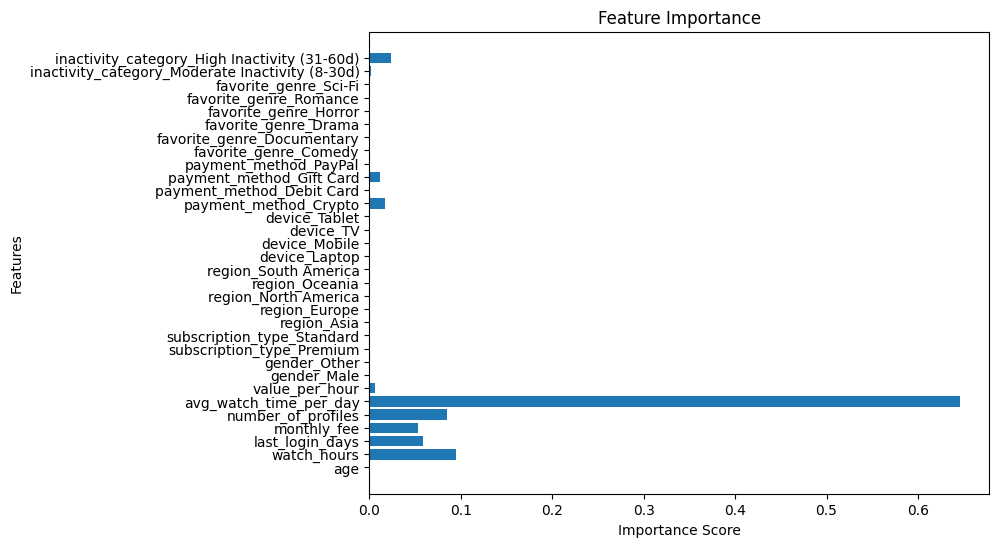

In [20]:
importance = model.feature_importances_

plt.figure(figsize=(8,6))
plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [21]:
import os

os.makedirs("../models", exist_ok=True)
joblib.dump(model, "../models/churn_model.pkl")

joblib.dump(model, "../models/churn_model.pkl")

['../models/churn_model.pkl']